# Wind speed, solar radiation and temperature at Sandheads during winters and early springs

According to `Hindcast of the timing of the spring phytoplankton bloom in the Strait of Georgia, 1968–2010`, wind speed and solar radiation during winter and early spring dominate the timing of spring bloom while temperature also has an impact (not on timing but the frequency of early blooms?).



## Data Extraction 

Following the methods of `Hindcast`, we extract the average winter (December–March) wind speed, solar radiation and temperature data from `CaSR` and `HRDPS` at Sandheads.

In [1]:
# Paths

# CaSR fnames and variable names

base_path_casr = '/ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/'

fname_FB  = 'Integrated_RDPS_P_FB_SFC_2008_2024.nc' # Solar radiation
fname_FI  = 'Integrated_RDPS_P_FI_SFC_2008_2024.nc' # Incoming infrared flux 
fname_TT  = 'Integrated_RDPS_P_TT_1.5m_2008_2024.nc' # Temperature (deg_C)
fname_UUC = 'Integrated_RDPS_P_UUC_10m_2008_2024.nc' # U wind (knot)
fname_VVC = 'Integrated_RDPS_P_VVC_10m_2008_2024.nc' # V wind (knot)

variable_FB = 'CaSR_v3.2_P_FB_SFC'
variable_FI = 'CaSR_v3.2_P_FI_SFC'
variable_TT = 'CaSR_v3.2_P_TT_1.5m'
variable_UUC = 'CaSR_v3.2_P_UUC_10m'
variable_VVC = 'CaSR_v3.2_P_VVC_10m'

# HRDPS

base_path_hrdps='/results/forcing/atmospheric/GEM2.5/operational/'

# Example fname: ops_y2018m01d01.nc

variable_solar = 'solar'
variable_temperature = 'tair' # K
variable_therm_radiation = 'therm_rad' 
variable_uu = 'u_wind' # m/s
variable_vv = 'v_wind'

In [ ]:
# DJFM Means at Sandheads: CaSR vs HRDPS

import os
import glob
import warnings

import xarray as xr
import numpy as np
import pandas as pd


# ================= 配置参数 =================

target_lat = 49.11
target_lon = -123.3

# winter_year = 2019 means 2018 Dec + 2019 Jan/Feb/Mar
winter_years = [2018, 2019, 2020, 2021, 2022]

output_csv = "Sandheads_DJFM_Mean_CaSR_vs_HRDPS.csv"

# 是否额外保存每个冬季的 daily mean 文件
save_daily_csv = False
daily_output_dir = "Sandheads_DJFM_Daily"



# ================= Unit conversions =================

KNOT_TO_MPS = 0.514444
KELVIN_TO_C_OFFSET = 273.15


# ================= Helper functions =================

def normalize_target_lon(lon_array, target_lon):
    """
    If model longitude is 0..360 but target_lon is -180..180,
    convert target_lon to model convention.
    """
    lon_min = np.nanmin(lon_array)
    lon_max = np.nanmax(lon_array)

    if lon_min >= 0 and target_lon < 0:
        return target_lon + 360.0

    if lon_max <= 180 and target_lon > 180:
        return ((target_lon + 180.0) % 360.0) - 180.0

    return target_lon


def find_closest_index(lat_array, lon_array, target_lat, target_lon):
    """
    Find nearest point in a 2D lat/lon grid.
    """
    target_lon_adj = normalize_target_lon(lon_array, target_lon)

    dist = (lat_array - target_lat) ** 2 + (lon_array - target_lon_adj) ** 2
    dist = np.where(np.isfinite(dist), dist, np.inf)

    return np.unravel_index(np.argmin(dist), dist.shape)


def get_coord(ds, names):
    """
    Return first available coordinate/data variable from candidate names.
    """
    for name in names:
        if name in ds.coords:
            return ds[name]
        if name in ds.data_vars:
            return ds[name]
    raise KeyError(f"Cannot find any of these coordinates: {names}")


def remove_time_dim_from_coord(coord_da):
    """
    For coordinates like nav_lat(time_counter, y, x), take the first time slice.
    """
    da = coord_da
    for dim in list(da.dims):
        if "time" in dim.lower():
            da = da.isel({dim: 0})
    return da


def build_point_locator(
    ds,
    target_lat,
    target_lon,
    lat_names=("lat", "latitude", "nav_lat", "rlat"),
    lon_names=("lon", "longitude", "nav_lon", "rlon"),
):
    """
    Build a locator dictionary for nearest-grid extraction.
    Works for both 2D lat/lon grids and 1D coordinate grids.
    """
    lat_da = remove_time_dim_from_coord(get_coord(ds, lat_names))
    lon_da = remove_time_dim_from_coord(get_coord(ds, lon_names))

    lat_vals = lat_da.values
    lon_vals = lon_da.values
    target_lon_adj = normalize_target_lon(lon_vals, target_lon)

    if lat_da.ndim >= 2 and lon_da.ndim >= 2:
        iy, ix = find_closest_index(lat_vals, lon_vals, target_lat, target_lon)

        y_dim = lat_da.dims[-2]
        x_dim = lat_da.dims[-1]

        return {
            "method": "isel",
            "indexer": {y_dim: iy, x_dim: ix},
            "grid_lat": float(lat_vals[iy, ix]),
            "grid_lon": float(lon_vals[iy, ix]),
            "target_lon_used": float(target_lon_adj),
        }

    else:
        # 1D coordinates
        lat_dim = lat_da.dims[0]
        lon_dim = lon_da.dims[0]

        iy = int(np.nanargmin((lat_vals - target_lat) ** 2))
        ix = int(np.nanargmin((lon_vals - target_lon_adj) ** 2))

        return {
            "method": "isel",
            "indexer": {lat_dim: iy, lon_dim: ix},
            "grid_lat": float(lat_vals[iy]),
            "grid_lon": float(lon_vals[ix]),
            "target_lon_used": float(target_lon_adj),
        }


def select_point(da, locator):
    """
    Select nearest point using a pre-built locator.
    """
    return da.isel(locator["indexer"])


def get_time_dim_name(obj):
    """
    Detect time dimension name.
    """
    for name in ["time", "time_counter"]:
        if name in obj.dims or name in obj.coords:
            return name

    for dim in obj.dims:
        if "time" in dim.lower():
            return dim

    raise KeyError("Cannot find time dimension.")


def subset_time(da, start_time, end_time):
    """
    Subset a DataArray by its time dimension.
    """
    time_dim = get_time_dim_name(da)
    return da.sel({time_dim: slice(start_time, end_time)})


def make_daily_dataframe(data_dict):
    """
    Convert selected point DataArrays into a daily-mean pandas DataFrame.
    """
    ds = xr.Dataset(data_dict)

    time_dim = get_time_dim_name(ds)

    if time_dim != "time":
        ds = ds.rename({time_dim: "time"})

    ds = ds.sortby("time")
    ds = ds.compute()

    cols = list(data_dict.keys())
    df = ds[cols].to_dataframe()[cols]

    if isinstance(df.index, pd.MultiIndex):
        df = df.reset_index().set_index("time")

    df.index = pd.to_datetime(df.index)

    return df.resample("D").mean()


def hrdps_preprocess(ds):
    """
    Keep only variables needed from HRDPS files.
    """
    vars_to_keep = [
        variable_solar,
        variable_temperature,
        variable_therm_radiation,
        variable_uu,
        variable_vv,
        "nav_lat",
        "nav_lon",
    ]

    return ds[[v for v in vars_to_keep if v in ds.data_vars or v in ds.coords]]


def get_djfm_period(winter_year):
    """
    winter_year = 2019 means 2018-12-01 to 2019-03-31.
    """
    start_time = pd.Timestamp(winter_year - 1, 12, 1)
    end_time = pd.Timestamp(winter_year, 3, 31, 23, 59, 59)

    return start_time, end_time


def get_hrdps_files_for_djfm(winter_year):
    """
    Get HRDPS files for Dec of previous year and Jan-Mar of winter_year.
    """
    months = [
        (winter_year - 1, 12),
        (winter_year, 1),
        (winter_year, 2),
        (winter_year, 3),
    ]

    files = []

    for yy, mm in months:
        pattern = os.path.join(base_path_hrdps, f"ops_y{yy}m{mm:02d}*.nc")
        files.extend(sorted(glob.glob(pattern)))

    return files


def extract_casr_daily(ds_casr, casr_locator, start_time, end_time):
    """
    Extract daily means from CaSR at target point.
    """
    solar = subset_time(
        select_point(ds_casr["FB"][variable_FB], casr_locator),
        start_time,
        end_time,
    )

    infrared = subset_time(
        select_point(ds_casr["FI"][variable_FI], casr_locator),
        start_time,
        end_time,
    )

    tair_c = subset_time(
        select_point(ds_casr["TT"][variable_TT], casr_locator),
        start_time,
        end_time,
    )

    u_knot = subset_time(
        select_point(ds_casr["UUC"][variable_UUC], casr_locator),
        start_time,
        end_time,
    )

    v_knot = subset_time(
        select_point(ds_casr["VVC"][variable_VVC], casr_locator),
        start_time,
        end_time,
    )

    u_mps = u_knot * KNOT_TO_MPS
    v_mps = v_knot * KNOT_TO_MPS
    wind_speed_mps = np.hypot(u_mps, v_mps)

    return make_daily_dataframe(
        {
            "CaSR_Solar": solar,
            "CaSR_Infrared": infrared,
            "CaSR_Tair_C": tair_c,
            "CaSR_WindSpeed_mps": wind_speed_mps,
        }
    )


def extract_hrdps_daily(files, start_time, end_time):
    """
    Extract daily means from HRDPS at target point.
    """
    if len(files) == 0:
        warnings.warn(f"No HRDPS files found for {start_time.date()} to {end_time.date()}")
        return pd.DataFrame(), None

    ds_hrdps = xr.open_mfdataset(
        files,
        preprocess=hrdps_preprocess,
        combine="nested",
        concat_dim="time_counter",
        parallel=True,
        chunks={"time_counter": 24},
    )

    try:
        ds_hrdps = ds_hrdps.sortby("time_counter")

        hrdps_locator = build_point_locator(
            ds_hrdps,
            target_lat,
            target_lon,
            lat_names=("nav_lat",),
            lon_names=("nav_lon",),
        )

        solar = subset_time(
            select_point(ds_hrdps[variable_solar], hrdps_locator),
            start_time,
            end_time,
        )

        infrared = subset_time(
            select_point(ds_hrdps[variable_therm_radiation], hrdps_locator),
            start_time,
            end_time,
        )

        tair_k = subset_time(
            select_point(ds_hrdps[variable_temperature], hrdps_locator),
            start_time,
            end_time,
        )

        tair_c = tair_k - KELVIN_TO_C_OFFSET

        u_mps = subset_time(
            select_point(ds_hrdps[variable_uu], hrdps_locator),
            start_time,
            end_time,
        )

        v_mps = subset_time(
            select_point(ds_hrdps[variable_vv], hrdps_locator),
            start_time,
            end_time,
        )

        wind_speed_mps = np.hypot(u_mps, v_mps)

        df_daily = make_daily_dataframe(
            {
                "HRDPS_Solar": solar,
                "HRDPS_Infrared": infrared,
                "HRDPS_Tair_C": tair_c,
                "HRDPS_WindSpeed_mps": wind_speed_mps,
            }
        )

    finally:
        ds_hrdps.close()

    return df_daily, hrdps_locator


# ================= Main script =================

print("Opening CaSR integrated files...")

ds_casr = {
    "FB": xr.open_dataset(os.path.join(base_path_casr, fname_FB)),
    "FI": xr.open_dataset(os.path.join(base_path_casr, fname_FI)),
    "TT": xr.open_dataset(os.path.join(base_path_casr, fname_TT)),
    "UUC": xr.open_dataset(os.path.join(base_path_casr, fname_UUC)),
    "VVC": xr.open_dataset(os.path.join(base_path_casr, fname_VVC)),
}

print("Locating nearest CaSR grid point...")

casr_locator = build_point_locator(
    ds_casr["FB"],
    target_lat,
    target_lon,
    lat_names=("lat", "latitude", "nav_lat", "rlat"),
    lon_names=("lon", "longitude", "nav_lon", "rlon"),
)

print(
    "CaSR nearest grid point:",
    f"lat={casr_locator['grid_lat']:.5f},",
    f"lon={casr_locator['grid_lon']:.5f}",
)

if save_daily_csv:
    os.makedirs(daily_output_dir, exist_ok=True)


output_columns = [
    "CaSR_Solar",
    "CaSR_Infrared",
    "CaSR_Tair_C",
    "CaSR_WindSpeed_mps",
    "HRDPS_Solar",
    "HRDPS_Infrared",
    "HRDPS_Tair_C",
    "HRDPS_WindSpeed_mps",
]

summary_rows = []

for winter_year in winter_years:
    start_time, end_time = get_djfm_period(winter_year)

    print(
        f"\n================= Processing DJFM winter {winter_year}: "
        f"{start_time.date()} to {end_time.date()} ================="
    )

    # ---------- CaSR ----------
    print(f"[DJFM {winter_year}] Extracting CaSR daily means...")
    df_casr_daily = extract_casr_daily(ds_casr, casr_locator, start_time, end_time)

    # ---------- HRDPS ----------
    print(f"[DJFM {winter_year}] Finding HRDPS files...")
    hrdps_files = get_hrdps_files_for_djfm(winter_year)

    print(f"[DJFM {winter_year}] Found {len(hrdps_files)} HRDPS files.")

    print(f"[DJFM {winter_year}] Extracting HRDPS daily means...")
    df_hrdps_daily, hrdps_locator = extract_hrdps_daily(
        hrdps_files,
        start_time,
        end_time,
    )

    # ---------- Combine daily data ----------
    df_daily = pd.concat([df_casr_daily, df_hrdps_daily], axis=1).sort_index()

    # Keep only DJFM period, just in case
    df_daily = df_daily.loc[start_time.normalize():end_time.normalize()]

    if save_daily_csv:
        daily_fname = os.path.join(
            daily_output_dir,
            f"Sandheads_DJFM_{winter_year}_Daily_CaSR_vs_HRDPS.csv",
        )
        df_daily.to_csv(daily_fname)
        print(f"[DJFM {winter_year}] Daily data saved to {daily_fname}")

    # ---------- Seasonal average ----------
    expected_days = (end_time.normalize() - start_time.normalize()).days + 1

    means = df_daily.mean(numeric_only=True)
    counts = df_daily.count()

    row = {
        "winter_year": winter_year,
        "start_date": start_time.date(),
        "end_date": end_time.date(),
        "target_lat": target_lat,
        "target_lon": target_lon,
        "CaSR_grid_lat": casr_locator["grid_lat"],
        "CaSR_grid_lon": casr_locator["grid_lon"],
        "expected_days": expected_days,
    }

    if hrdps_locator is not None:
        row["HRDPS_grid_lat"] = hrdps_locator["grid_lat"]
        row["HRDPS_grid_lon"] = hrdps_locator["grid_lon"]
    else:
        row["HRDPS_grid_lat"] = np.nan
        row["HRDPS_grid_lon"] = np.nan

    for col in output_columns:
        row[col] = means.get(col, np.nan)

    for col in output_columns:
        row[f"{col}_n_days"] = int(counts.get(col, 0))

    row["n_days_all_variables_valid"] = int(df_daily[output_columns].dropna().shape[0])

    summary_rows.append(row)

    print(f"[DJFM {winter_year}] Seasonal means calculated.")


# ================= Save summary CSV =================

df_summary = pd.DataFrame(summary_rows)

front_cols = [
    "winter_year",
    "start_date",
    "end_date",
    "target_lat",
    "target_lon",
    "CaSR_grid_lat",
    "CaSR_grid_lon",
    "HRDPS_grid_lat",
    "HRDPS_grid_lon",
    "expected_days",
    "n_days_all_variables_valid",
]

mean_cols = output_columns
count_cols = [f"{col}_n_days" for col in output_columns]

df_summary = df_summary[front_cols + mean_cols + count_cols]

df_summary.to_csv(output_csv, index=False)

print(f"\nDJFM seasonal summary saved to {output_csv}")


# ================= Close CaSR files =================

for ds in ds_casr.values():
    ds.close()

print("\nAll done!")

## Visualization

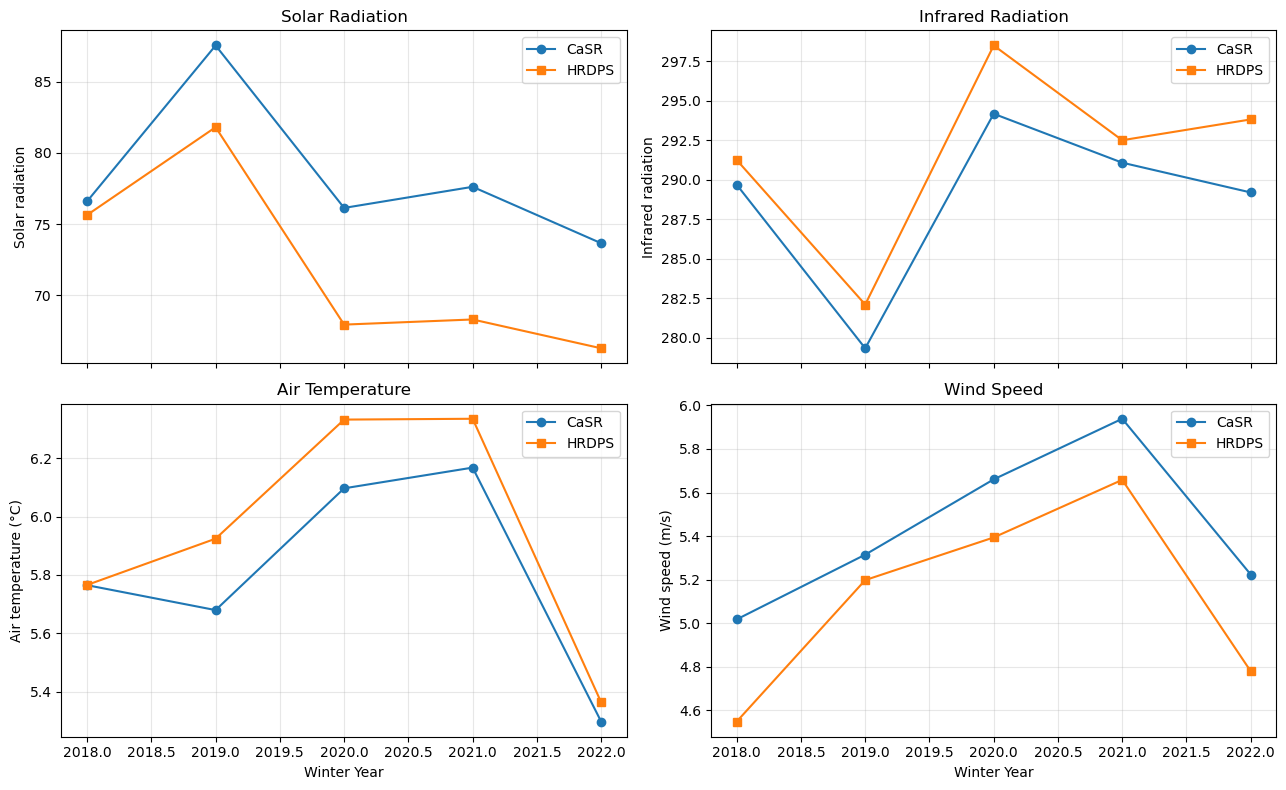

In [4]:
import pandas as pd
import matplotlib.pyplot as plt


csv_file = "Sandheads_DJFM_Mean_CaSR_vs_HRDPS.csv"

df = pd.read_csv(csv_file)
df = df.sort_values("winter_year")

variables = [
    {
        "casr": "CaSR_Solar",
        "hrdps": "HRDPS_Solar",
        "ylabel": "Solar radiation",
        "title": "Solar Radiation",
    },
    {
        "casr": "CaSR_Infrared",
        "hrdps": "HRDPS_Infrared",
        "ylabel": "Infrared radiation",
        "title": "Infrared Radiation",
    },
    {
        "casr": "CaSR_Tair_C",
        "hrdps": "HRDPS_Tair_C",
        "ylabel": "Air temperature (°C)",
        "title": "Air Temperature",
    },
    {
        "casr": "CaSR_WindSpeed_mps",
        "hrdps": "HRDPS_WindSpeed_mps",
        "ylabel": "Wind speed (m/s)",
        "title": "Wind Speed",
    },
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)

axes = axes.ravel()

for ax, var in zip(axes, variables):
    ax.plot(
        df["winter_year"],
        df[var["casr"]],
        marker="o",
        label="CaSR"
    )

    ax.plot(
        df["winter_year"],
        df[var["hrdps"]],
        marker="s",
        label="HRDPS"
    )

    ax.set_title(var["title"])
    ax.set_ylabel(var["ylabel"])
    ax.grid(True, alpha=0.3)
    ax.legend()

for ax in axes[-2:]:
    ax.set_xlabel("Winter Year")


plt.tight_layout()
plt.show()